# Artificial Neural Networks with Pytorch

In this notebook we will see how to use Pytorch to train ANNs and avoid needing to extract features like we did in the previous notebook. We will first translate the data into test and training sets, and then try to fit the model using a simple neural network.

In [1]:
# Grab the same digit data we used before
! git clone https://github.com/Jakobovski/free-spoken-digit-dataset.git

fatal: destination path 'free-spoken-digit-dataset' already exists and is not an empty directory.


In [2]:
#Change directories
import os
os.chdir('free-spoken-digit-dataset/recordings')

In [3]:
#Put all wav file names in a list

import glob, os

wavfiles = list()
for file in glob.glob("*.wav"):
    wavfiles.append(file)

n_audio_samples = len(wavfiles)

print('{} audio samples\n'.format(n_audio_samples))

# list the first few files
wavfiles[:10]


3000 audio samples



['0_george_0.wav',
 '0_george_1.wav',
 '0_george_10.wav',
 '0_george_11.wav',
 '0_george_12.wav',
 '0_george_13.wav',
 '0_george_14.wav',
 '0_george_15.wav',
 '0_george_16.wav',
 '0_george_17.wav']

In [4]:
#Import modules that we plan on using for training and plotting results

import numpy as np
import scipy.io.wavfile
from IPython.display import Audio
import matplotlib.pyplot as plt
import matplotlib
from sklearn import metrics

%matplotlib inline
matplotlib.rcParams.update({'font.size': 16,'figure.figsize':(10,6)})


## Load the data from audio files into variables

In [5]:
#Load regular expression module so we can get speaker name and spoken digit 
#from each file name and use those to create labels for the data

#Note: regular expressions are not just a python thing, they represent a general
#method to check if strings match a general pattern, and return desired portions
#of that match. In this case, we are using regular expressions to get the digit,
#speaker, and trial number from each file's name, knowing that the format of 
#each file name fits the form "<digit>_<speaker>_<trial_num>.wav".

import re

re_digit = re.compile('\d+_')
re_speaker = re.compile('_[a-z]+_')
re_trial = re.compile('_\d+.')

In [6]:
#Iterate over each data file to put the signal data samples into each element of
#X_data. Then populate the lists of speaker labels and digit labels based on each
#file name (y_speaker_labels and y_digit_labels, respectively)

X_data = np.ndarray(shape=(n_audio_samples,),dtype=object)
y_speaker_labels = list()
y_digit_labels = list()

for ind, sample_file in enumerate(wavfiles):
  try:

    #Get digit and speaker from this sample    
    digit = int(re.match( re_digit, sample_file)[0][:-1])
    speaker = re.search( re_speaker, sample_file)[0][1:-1]

    # read in data from file
    (sample_rate, signal) = scipy.io.wavfile.read(sample_file)
    
    # some files have two channels... just take the first one
    if len(signal.shape) == 2:
      signal = signal[:,0]

    #Load the sample data into row <ind> of X_data
    X_data[ind,] = np.array(signal)
    
    #Load speaker and digit into their respective lists
    y_speaker_labels.append(speaker)
    y_digit_labels.append(digit)

  except Exception as e:
    
    # something went wrong!  =(
    
    print(sample_file)
    print(e)
    print(X_data.shape)
    print(signal.shape)
    
    break

## Standardize the length of audio inputs
Each .wav file is a different duration.  The artificial neural net we are building will expect inputs to be of the same size.  Let's artifically pad or truncate our input vectors so they're all the same length.  (Warning: we may lose data!)

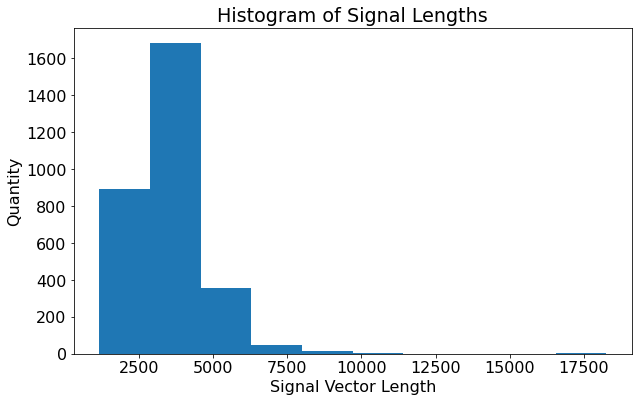

In [7]:
#Let's look at how long the signal vectors are to see what a good "standard length" might be

plt.figure()
plt.hist([len(x) for x in X_data])
plt.xlabel('Signal Vector Length')
plt.ylabel('Quantity')
plt.title('Histogram of Signal Lengths')

X_data_untrimmed = X_data.copy() #store old X_data before we overwrite

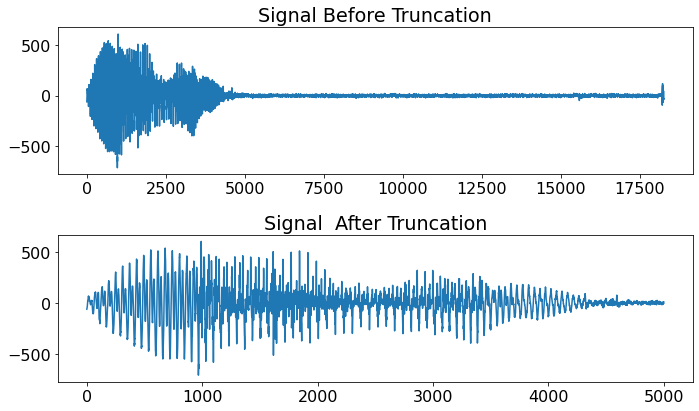

In [8]:
#Let's standardize inputs to length 5000 in light of the above histogram

desired_length = 5000

for ix in range(X_data.shape[0]): #iterate over elements in X_data
  
  if X_data[ix].shape[0] < desired_length:
    pad_len = desired_length - X_data[ix].shape[0]
    X_data[ix] = np.append(X_data[ix],np.mean(X_data[ix])*np.ones(pad_len))
    
  elif X_data[ix].shape[0] > desired_length:
    X_data[ix] = X_data[ix][:desired_length]
    
  # remove the mean
  X_data[ix] = X_data[ix]-np.mean(X_data[ix])

s_plot_ix = max(range(len(X_data_untrimmed)),
                key = lambda x:len(X_data_untrimmed[x]))   # get element with max length (for demonstration)
plt.subplot(2,1,1)
plt.plot(X_data_untrimmed[s_plot_ix])
plt.title('Signal Before Truncation')

plt.subplot(2,1,2)
plt.plot(X_data[s_plot_ix])
plt.title('Signal  After Truncation')

#make sure text doesn't overlap between plots
plt.tight_layout()            

In [9]:
# Change the elements of y_labels vector into integers (currently they are strings) 
# and make y_labels into a np.array
# (so we can manipulate it similarly to X_labels)

# Set y_labels based on what output (speaker or digit) you want the network to learn
y_labels = y_speaker_labels.copy()

#convert labels into integers (needed to convert y_labels to one_hot encoding)
name2int_dict = {x: i for i, x in enumerate(set(y_labels))}

y_labels = np.array([name2int_dict[label] for label in y_labels]) #ylabels now are all integers

print('Old y_labels (strings in list):')
print(y_speaker_labels[:10])
print('\n')

print('New y_labels (integers in numpy array):')
print(y_labels[:10])


Old y_labels (strings in list):
['george', 'george', 'george', 'george', 'george', 'george', 'george', 'george', 'george', 'george']


New y_labels (integers in numpy array):
[4 4 4 4 4 4 4 4 4 4]


## Split data into test/train split

In [10]:
from sklearn.model_selection import train_test_split
import pandas as pd

# split X and y into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(X_data, np.array(y_labels), test_size=0.25)
X_train, X_test, y_train, y_test = train_test_split(X_data, y_labels, test_size=0.25)

print(f'Data has been split into {len(y_train)} train sampes and {len(y_test)} test samples')

n_classes = max(set(y_labels))+1 # Get number of distinct classes so we know how large to make the plot

Data has been split into 2250 train sampes and 750 test samples


## Modeling in Pytorch

See Pytorch sequential API documentation online for more information

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim

# Pytorch does everything in terms of 'tensors' so we need to turn our data into Pytorch tensors
X_train_list = []
for x in X_train:
  X_train_list.append(x)
X_train = torch.tensor(np.array(X_train_list), dtype=torch.float32) # Notice that our features are torch float 32
del X_train_list

X_test_list = []
for x in X_test:
  X_test_list.append(x)
X_test = torch.tensor(np.array(X_test_list), dtype=torch.float32)
del X_test_list

y_train = torch.tensor(y_train, dtype=torch.long) # Notice that our class labels are torch long
y_test = torch.tensor(y_test, dtype=torch.long)


## Training

In [12]:
epochs = 10
batch_size = 64

train = torch.utils.data.TensorDataset(
    X_train,
    y_train
)
train_loader = torch.utils.data.DataLoader(train, batch_size=batch_size, shuffle=False)

model = nn.Sequential(
    nn.Linear(5000, 32),
    nn.ReLU(),

    nn.Linear(32, n_classes),
)

optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

history = []
for epoch in range(epochs):
    for i, data in enumerate(train_loader):
        # Train loop
        model.train()
        inputs, labels = data

        # Pytorch keeps track of gradients across loops, so we need to zero it for each batch
        # We need to manually zero the gradient--reset it--every batch
        optimizer.zero_grad()
 
        outputs = model(inputs) # Get the model's output
        loss = criterion(outputs, labels) # Compute the loss
        preds = torch.argmax(outputs,dim=1)

        # For monitoring
        tr_loss = loss.item()
        tr_acc = torch.sum(preds==labels)/len(labels)

        if i%5 == 0: # logging every 5 batches
            history.append(tr_acc)

        loss.backward() # Backpropagate to compute gradient
        optimizer.step() # Update the parameters, according to chosen optimizer algorithm

final trainning accuracy: 0.90


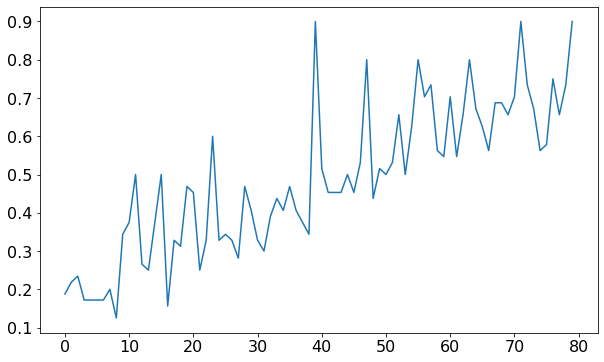

In [13]:
# plot metrics
print(f'final trainning accuracy: {history[-1]:.2f}')
plt.plot(history)
plt.show()

## Testing
Now that we have trained our model, we want to evaluate it. The training accuracy was quite high great (90%, depending on the random seed), but some of this could be due to overfitting the input dataset.  Let's see how well we do on our test data.

In [15]:
# We can check our model's metrics by using the model.evaluate function and 
# providing the test data and labels as inputs

model.eval()
output = model(X_test)
y_pred = torch.argmax(output, dim=1)
accuracy = torch.sum(y_pred == y_test)/len(y_test)
print('Test accuracy: %.2f' % (accuracy))

Test accuracy: 0.29


## Having built a model (albeit overfit), let's plot its confusion matrix

In [16]:
# Create function to visualize the confusion matrix

int2name_dict = {val: key for key, val in name2int_dict.items()}

import seaborn as sns

def plot_cmatrix(cm,labels,title='Confusion Matrix', **kwargs):
  fig = plt.figure()
  ax = fig.add_subplot(111)
  cax = sns.heatmap(cm, **kwargs)
  plt.title('\n'+title+'\n', fontsize=20)
  # fig.colorbar(cax)
  ax.set_xticks(np.arange(len(labels))+0.5)
  ax.set_yticks(np.arange(len(labels))+0.5)
  ax.set_xticklabels([int2name_dict[label] for label in labels], fontsize=16)
  ax.set_yticklabels([int2name_dict[label] for label in labels], fontsize=16)
  plt.xlabel('Predicted', fontsize=16)
  plt.ylabel('True', fontsize=16)
  plt.yticks(rotation=0)
  plt.show()
  

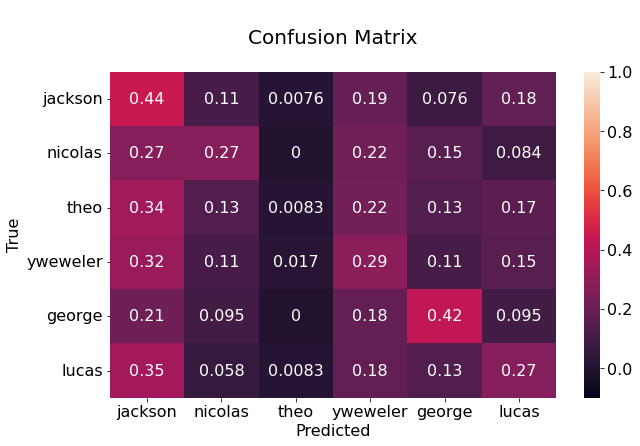

In [17]:
cm = metrics.confusion_matrix(y_test, y_pred, normalize = 'true')
plot_cmatrix(cm, range(n_classes), vmax = 0, vmin = 1, annot = True)


### Conclusions
As you can see, this is actually a pretty terrible classifier!
* Play around with some of the model parameters to see if you can make it better.  Later we'll see how we can use convolutions to solve a similar problem!
* You could also try to see if you can train a better classifier using the frequency spectrum instead of the raw signal